# Ôn tập giữa kỳ


In [439]:

# import library...
# ...
import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import seaborn as sns

## ĐỀ BÀI

Hệ thống giám sát rủi ro dựa trên hành vi (The Behavior Risk Factor Surveilance System - BRFSS) là một cuộc khảo sát qua điện thoại hàng năm với 350.000 người ở Hoa Kỳ. Như tên gọi của nó, BRFSS được thiết kế để xác định các yếu tố nguy cơ ở người trưởng thành và báo cáo các xu hướng sức khỏe mớ. Ví dụ, người trả lời được hỏi về chế độ ăn uống và hoạt động thể chất hàng tuần, tình trạng HIV/AIDS, khả năng sử dụng thuốc lá và thậm chí cả mức độ chi trả dịch vụ chăm sóc sức khỏe của họ. 

Bộ dữ liệu **brfss_2000** chứa thông tin khảo sát năm 2000, với hơn 200 thông tin. Trong bộ dữ liệu này, ta chỉ khảo sát một số thông tin sau:
-	genhlth: người khảo sát tự đánh giá sức khỏe (excellent, very good, good, fair or poor)
-	exerany: cho biết có hoạt động thể chất nào trong tháng gần nhất hay không, có (1), không (0)
-	hlthplan: có bảo hiểm (1) hay không (0)
-	smoke100: tổng số điếu thuốc đã hút ít nhất
-	height: chiều cao (inches)
-	weight: cân nặng (pounds)
-	wtdesire:  cân nặng mong muốn(pounds)
-	age: tuổi
-	gender: giới tính: nam(m), nữ(f)


### Câu 1:

Đọc hai bộ dữ liệu trên và cho biết mỗi bộ dữ liệu có kích thước bao nhiêu dòng, bao nhiêu cột?

In [440]:
df = pd.read_csv('brfss_2000.csv')
df

,exerany,hlthplan,smoke100,height,weight,wtdesire,age,gender,genhlth
0,0,1,0,70,175,175,77,m,good
1,0,1,1,64,125,115,33,f,good
2,1,1,1,60,105,105,49,f,good
3,1,1,0,66,132,124,42,f,good
4,0,1,0,61,150,130,55,f,very good
...,...,...,...,...,...,...,...,...,...
19995,1,1,0,66,215,140,23,f,good
19996,0,1,0,73,200,185,35,m,excellent
19997,0,1,0,65,216,150,57,f,poor
19998,1,1,0,67,165,165,81,f,good


In [441]:
df.shape

(20000, 9)

### Câu 2

a, Tính tỷ lệ nam nữ

b, Trong số những người tập thể thao, tỷ lệ những người tự đánh giá có sức khỏe kém là bao nhiêu?

In [442]:
male = len(df[df['gender'] == 'm'])
total = len(df)

percent_male = male / total
percent_female = 1 - percent_male

print(percent_male, percent_female)

0.47845 0.52155


In [443]:
unhealthy_people = len(df[df['genhlth'] == 'poor'])

percent_unhealthy = unhealthy_people / total
print(percent_unhealthy)

0.03385


### Câu 3

a, Đổi đơn vị chiều cao từ inches sang centimet, đơn vị cân nặng từ pound sang kg.

b, Tính tỷ lệ những người muốn giảm cân.

In [444]:
df['height'] = df['height'] * 2.54
df['weight'] = df['weight'] * 0.45359
df['wtdesire'] = df['wtdesire'] * 0.45359
df

,exerany,hlthplan,smoke100,height,weight,wtdesire,age,gender,genhlth
0,0,1,0,177.80,79.37825,79.37825,77,m,good
1,0,1,1,162.56,56.69875,52.16285,33,f,good
2,1,1,1,152.40,47.62695,47.62695,49,f,good
3,1,1,0,167.64,59.87388,56.24516,42,f,good
4,0,1,0,154.94,68.03850,58.96670,55,f,very good
...,...,...,...,...,...,...,...,...,...
19995,1,1,0,167.64,97.52185,63.50260,23,f,good
19996,0,1,0,185.42,90.71800,83.91415,35,m,excellent
19997,0,1,0,165.10,97.97544,68.03850,57,f,poor
19998,1,1,0,170.18,74.84235,74.84235,81,f,good


In [445]:
loose_weight = df[df['weight'] > df['wtdesire']]
loose_weight =  len(loose_weight)

percent_loose_weight = loose_weight / total
print(percent_loose_weight)

0.6382


In [446]:
df.head(20)

,exerany,hlthplan,smoke100,height,weight,wtdesire,age,gender,genhlth
0,0,1,0,177.80,79.37825,79.37825,77,m,good
1,0,1,1,162.56,56.69875,52.16285,33,f,good
2,1,1,1,152.40,47.62695,47.62695,49,f,good
3,1,1,0,167.64,59.87388,56.24516,42,f,good
4,0,1,0,154.94,68.03850,58.96670,55,f,very good
5,1,1,0,162.56,51.70926,51.70926,55,f,very good
6,1,1,0,180.34,87.99646,83.91415,31,m,very good
7,0,1,0,170.18,77.11030,72.57440,45,m,very good
8,0,1,1,165.10,68.03850,58.96670,27,f,good
9,1,1,0,177.80,81.64620,77.11030,44,m,good


### Câu 4:

a, Theo bạn trong các thuộc tính trên, thuộc tính nào có phân phối chuẩn. Vẽ hình minh họa

b, Vẽ đồ thị boxplot so sánh cân nặng của những người có tập thể dục

Trong các thuộc tính trên thì thuộc tính ***height, weight, wtdesire, age***

Vẽ mình hình minh hoạ cho thuộc tính ***height*** với phân phối chuẩn

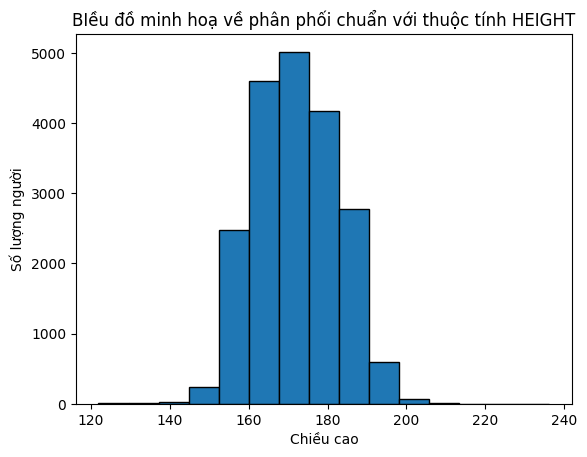

In [447]:
plt.hist(df['height'], bins=15, edgecolor='black')
plt.title("BIều đồ minh hoạ về phân phối chuẩn với thuộc tính HEIGHT")
plt.xlabel("Chiều cao")
plt.ylabel("Số lượng người")
plt.show()

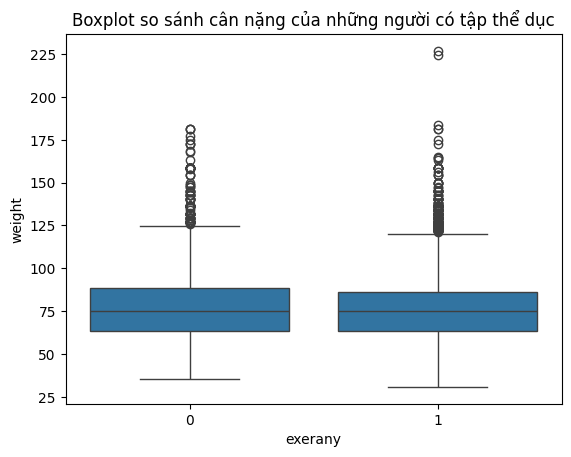

In [448]:
sns.boxplot(x='exerany', y='weight', data=df)
plt.title("Boxplot so sánh cân nặng của những người có tập thể dục")
plt.show()

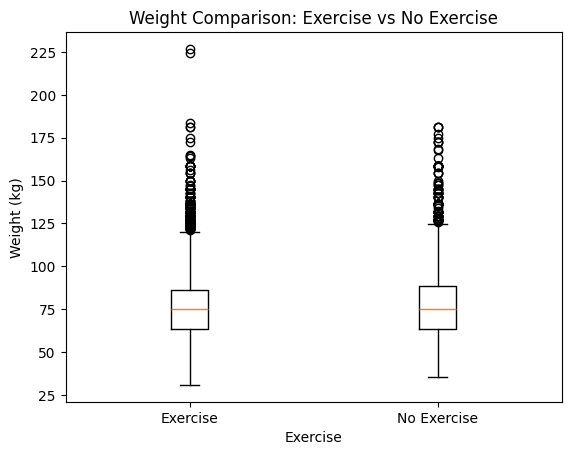

In [449]:
plt.boxplot([df[df['exerany'] == 1]['weight'], df[df['exerany'] == 0]['weight']])
plt.xticks([1, 2], ['Exercise', 'No Exercise'])
plt.xlabel('Exercise')
plt.ylabel('Weight (kg)')
plt.title('Weight Comparison: Exercise vs No Exercise')
plt.show()


### Câu 5

Phân bố tuổi tác trong mẫu: Hãy mô tả phân bố tuổi của người tham gia khảo sát. Tuổi trung bình, độ lệch chuẩn, và các phân vị 25%, 50%, 75% là bao nhiêu?



In [450]:
age_df = df['age']
age_df.describe()

count    20000.000000
mean        45.068250
std         17.192689
min         18.000000
25%         31.000000
50%         43.000000
75%         57.000000
max         99.000000
Name: age, dtype: float64

### Câu 6

Tỉ lệ người hút thuốc: Tính tỉ lệ phần trăm người tham gia khảo sát hiện đang hút thuốc lá. Liệu có sự khác biệt đáng kể về tỉ lệ này giữa các nhóm tuổi khác nhau không?



In [451]:
smoker = len(df[df['smoke100'] == 1])
percent_smoker = smoker / total * 100
print(round(percent_smoker, 5), '%')

47.205 %


In [452]:
age_smoker = df[['smoke100', 'age']]

vi_thanh_nien = age_smoker[(age_smoker['age'] < 20) & (age_smoker['age'] >= 12)]
# vi_thanh_nien = len(vi_thanh_nien)

thanh_nien = age_smoker[((age_smoker['age'] >= 20) & (age_smoker['age'] < 40))]
# thanh_nien = len(thanh_nien)

trung_nien = age_smoker[((age_smoker['age'] >= 40) & (age_smoker['age'] < 60))]
# trung_nien = len(trung_nien)

tuoi_gia = age_smoker[((age_smoker['age'] >= 60) & (age_smoker['age'] < 101))]
# tuoi_gia = len(tuoi_gia)


In [453]:
percent_vi_thanh_nien = len(vi_thanh_nien[vi_thanh_nien['smoke100'] == 1]) / len(vi_thanh_nien) * 100
percent_thanh_nien = len(thanh_nien[thanh_nien['smoke100'] == 1]) / len(thanh_nien) * 100
percent_trung_nien = len(trung_nien[trung_nien['smoke100'] == 1]) / len(trung_nien) * 100
percent_tuoi_gia = len(tuoi_gia[tuoi_gia['smoke100'] == 1]) / len(tuoi_gia) * 100

print(percent_vi_thanh_nien)
print(percent_thanh_nien)
print(percent_trung_nien)
print(percent_tuoi_gia)

34.29541595925297
40.467512881739346
51.887459352467125
53.61789545765807


In [454]:
smoke_percent_by_age = df.groupby('age')['smoke100'].mean() * 100
smoke_percent_by_age.head(20)

age
18    30.065359
19    38.869258
20    39.937107
21    44.000000
22    38.268156
23    39.632546
24    43.051771
25    34.246575
26    41.228070
27    38.167939
28    41.500000
29    38.072289
30    37.280702
31    43.059490
32    34.052758
33    38.405797
34    39.593909
35    42.584746
36    42.988506
37    42.580645
Name: smoke100, dtype: float64

### Câu 7

BMI trung bình theo giới tính: Tính chỉ số BMI trung bình cho nam và nữ trong mẫu. 



In [455]:
new_df = df[['height', 'weight', 'gender', 'age']]
bmi = new_df['weight'] / ((new_df['height'] / 100) ** 2)
new_df.insert(3, 'bmi', bmi)
new_df.head()

,height,weight,gender,bmi,age
0,177.80,79.37825,m,25.109497,77
1,162.56,56.69875,f,21.455869,33
2,152.40,47.62695,f,20.506089,49
3,167.64,59.87388,f,21.305027,42
4,154.94,68.03850,f,28.341813,55


In [456]:
bmi_gender = new_df.groupby('gender')['bmi'].mean()
bmi_gender.head(20)

gender
f    25.743561
m    26.926194
Name: bmi, dtype: float64

### câu 8

Phân tích tỉ lệ bệnh béo phì: Sử dụng các tiêu chuẩn của CDC về chỉ số BMI để phân loại người tham gia vào nhóm béo phì. Tính tỉ lệ béo phì theo giới tính và độ tuổi. 

In [468]:
count_fat_people = new_df[new_df['bmi'] > 30]
count_fat_people

,height,weight,gender,bmi,age
34,162.56,99.78980,f,37.762329,57
44,162.56,90.71800,f,34.329390,65
57,157.48,76.20312,f,30.727126,43
62,185.42,113.39750,m,32.983013,36
63,152.40,72.57440,f,31.247374,56
...,...,...,...,...,...
19982,160.02,77.56389,f,30.290821,31
19989,185.42,104.32570,m,30.344372,38
19994,175.26,101.60416,m,33.078505,73
19995,167.64,97.52185,f,34.701370,23


---

In [481]:
male_fat = count_fat_people[count_fat_people['gender'] == 'm']
male_fat = len(male_fat)
female_fat = len(count_fat_people) - male_fat

per_male_fat = male_fat / len(count_fat_people) * 100
per_female_fat = female_fat / len(count_fat_people) * 100

print(per_female_fat, per_male_fat)


50.07780082987552 49.92219917012448


In [483]:
age_by_fat = count_fat_people.groupby('age')['bmi'].mean() * 100
age_by_fat.head(20)

age
18    3405.186250
19    3473.649337
20    3395.951911
21    3418.051695
22    3324.090738
23    3522.047449
24    3417.439857
25    3355.604285
26    3380.462158
27    3406.583730
28    3415.807357
29    3472.235286
30    3408.498951
31    3460.450668
32    3613.709978
33    3404.603024
34    3547.066096
35    3515.069957
36    3406.179194
37    3471.198244
Name: bmi, dtype: float64